# LM Lab: Neural models for word vector representation

- Alejandro Silva
- Fernando Baña
- Daniel Prieto

In [32]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("embeddings", exist_ok=True)

# Disable TensorFlow logging
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tqdm import tqdm
from utils import *
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FILE_PATH = "data/eng_news_2024_30k_sentences.txt"

## Data Cleaning and Preprocessing

We are given the txt file in the following format:

- Each line contains a sentence.
- Each sentence is a sequence of words separated by spaces.
- All sentences end with a period ('.').


In [33]:
text_data = load_dataset(FILE_PATH)

print(f"Loaded {len(text_data)} sentences")
print(f"First 5 sentences:")
for i in range(5):
    print(f"{i+1}: {text_data[i]}")

Loaded 30000 sentences
First 5 sentences:
1: $10-$15 suggested donation goes to Falmouth Land Trust.
2: $20,000: Lower Adirondack Pride Festival, June 1 in City Park, Glens Falls.
3: $239.4 billion (32nd), comparable to Hungary.
4: $35, $75 family of three or more.
5: £1,200: Provision of funding for Year 1 & Year 2 children to attend Enchantica Christmas Show / Grove Road Community Primary School.


## Word Embedding Models

In this section we will implement the required models. The models are based on the **prediction of words given their context**. The models will have the following characteristics:

- They will take as input the context, n words preciding/following the target word.
- They will try to predict the target word given the context.

Therefore we have:
- Input $\rightarrow$ Context (n words)
- Output $\rightarrow$ Target word

### Tokenization and Vocabulary Building

To implement the word embedding models, we first need to preprocess the text data. This involves tokenizing the sentences and building a vocabulary of unique words. For this task we will use the TextVectorizer from the Keras library, and use it to convert the sentences into sequences of integersmm, where each integer represents a unique word in the vocabulary.

We will use a limited vocabulary size to keep the models to train.

In [34]:
VOCAB_SIZE = 20000

vectorizer = build_vectorizer(text_data, VOCAB_SIZE)

# Get the vocabulary and create mappings from words to indices
vocab, word_to_index, index_to_word = build_vocab_mappings(vectorizer)
print(f"Vocabulary size: {len(vocab)}")
print(f"First 10 words in the vocabulary: {vocab[:10]}")

Vocabulary size: 20000
First 10 words in the vocabulary: ['', '[UNK]', 'the', 'to', 'and', 'of', 'a', 'in', 'for', 'on']


### Generating Training Data for the Models

Now that we have the vectorizer adapted to out data, we can start generating the training data for the models. We are going to use a sliding window of size `WINDOW_SIZE` approach to create the context/target pairs. That means that for each target word in the sentence we will take the `WINDOW_SIZE` words before and after it as the context. For instance if we have the sentence "the cat is on the roof" and a `WINDOW_SIZE` of 2, we will generate the following context/target pairs:

- Context: ["the", "cat"] Target: "is"
- Context: ["cat", "is"] Target: "on"
- Context: ["is", "on"] Target: "the"
- Context: ["on", "the"] Target: "roof"

We are going to generate window sizes of 2, 4 and 8, so it means we will have context lengths of 4, 8 and 16 respectively.


In [35]:
experiments = {}

WINDOW_SIZES = [2, 4, 8]  # Number of words to the left and right of the target word

sequences = vectorizer(text_data).numpy()
for WINDOW_SIZE in WINDOW_SIZES:
    print(f"\n Context-target pairs with window size: {WINDOW_SIZE}")
    # First transform the sentences into sequences of integers

    X_train, y_train = build_context_target_pairs(sequences, WINDOW_SIZE)

    print(f"Number of training samples: {len(X_train)}")
    print(f"Sample training data (context -> target):")
    print(f"Context: {X_train[0]} -> Target: {y_train[0]}")
    print(
        f"Context: {[str(index_to_word[idx]) for idx in X_train[0]]} -> Target: {index_to_word[y_train[0]]}"
    )

    experiments[WINDOW_SIZE] = (X_train, y_train)


 Context-target pairs with window size: 2


100%|██████████| 30000/30000 [00:00<00:00, 30113.93it/s]


Number of training samples: 470316
Sample training data (context -> target):
Context: [8437 1636  822    3] -> Target: 5602
Context: ['1015', 'suggested', 'goes', 'to'] -> Target: donation

 Context-target pairs with window size: 4


100%|██████████| 30000/30000 [00:00<00:00, 44884.31it/s]


Number of training samples: 354734
Sample training data (context -> target):
Context: [4675  855    1 3153  422  423    7  148] -> Target: 940
Context: ['20000', 'lower', '[UNK]', 'pride', 'june', '1', 'in', 'city'] -> Target: festival

 Context-target pairs with window size: 8


100%|██████████| 30000/30000 [00:00<00:00, 76707.39it/s] 

Number of training samples: 166319
Sample training data (context -> target):
Context: [14997  4470     5   699     8    75   423    75   229     3  1666     1
   999   182  6490   221] -> Target: 410
Context: ['£1200', 'provision', 'of', 'funding', 'for', 'year', '1', 'year', 'children', 'to', 'attend', '[UNK]', 'christmas', 'show', 'grove', 'road'] -> Target: 2


### Embedding Model Architecture

In [36]:
EMBEDDING_DIMS = [50, 100, 200]
EPOCHS = 20
BATCH_SIZE = 256

for WINDOW_SIZE in WINDOW_SIZES:
    # Populate the experiments dictionary with the combinations of window sizes and embedding dimensions
    for EMBEDDING_DIM in EMBEDDING_DIMS:
        experiments[(WINDOW_SIZE, EMBEDDING_DIM)] = {
            "embeddings": None,
            "model": None,
            "history": None,
        }

In [37]:
for WINDOW_SIZE in WINDOW_SIZES:
    X_train, y_train = experiments[WINDOW_SIZE]

    for EMBEDDING_DIM in EMBEDDING_DIMS:
        print(
            f"\nTraining CBOW model with window size {WINDOW_SIZE} and embedding dim {EMBEDDING_DIM}"
        )
        model = build_word_emb_model(VOCAB_SIZE, EMBEDDING_DIM, WINDOW_SIZE * 2)
        model.summary()

        save_path = (
            f"models/word_embed_w{WINDOW_SIZE}_emb{EMBEDDING_DIM}_v{VOCAB_SIZE}.keras"
        )

        callbacks = get_callbacks(save_path)

        history = model.fit(
            X_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            callbacks=callbacks,
        )

        # Save the trained embeddings
        trained_embeddings = model.get_layer("word_embeddings").get_weights()[0]

        # Save as a numpy array so it can be used later
        np.save(
            f"embeddings/embeddings_w{WINDOW_SIZE}_emb{EMBEDDING_DIM}_v{VOCAB_SIZE}.npy",
            trained_embeddings,
        )

        experiments[(WINDOW_SIZE, EMBEDDING_DIM)] = {
            "model": model,
            "history": history,
            "embeddings": trained_embeddings,
        }


Training CBOW model with window size 2 and embedding dim 50


Model: "word_emb_d50_c4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context_words (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ word_embeddings (Embedding)     │ (None, 4, 50)          │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_probs (Dense)            │ (None, 20000)          │     1,020,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,020,000 (7.71 MB)

 Trainable params: 2,020,000 (7.71 MB)

...

 Total params: 4,020,000 (15.34 MB)

 Trainable params: 4,020,000 (15.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 333/1654 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - accuracy: 0.0550 - loss: 9.0540

KeyboardInterrupt: 

## Analysis of the Results of Word Embeddings

In order to analyze the results from the different models we will use the following metrics:

- **Cosine Similarity**: To compare the similarity between the given target words and the results obtained from the models.
- **Visualization using t-SNE**: To visualize the word embeddings in a 2D space and observe how words are grouped together 

In [38]:
import pandas as pd
from IPython.display import display

tables = {}
with open("materials/target_words.txt", "r") as f:
    target_words = [w.strip() for w in f if w.strip() in word_to_index]


# Load the embeddings for each experiment:
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        embeddings_path = (
            f"embeddings/embeddings_w{w_size}_emb{e_dim}_v{VOCAB_SIZE}.npy"
        )
        experiments[(w_size, e_dim)]["embeddings"] = np.load(embeddings_path)

print("Top 10 similar words per target word:\n")
for word in target_words:
    print(f"Target word: {word}")

    table_data = {}

    for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
        if (w_size, e_dim) in experiments:
            col_name = f"W={w_size} | D={e_dim}"

            # Get the trained embeddings matrix for this specific model
            embeddings = experiments[(w_size, e_dim)]["embeddings"]

            # Get the top 10 similar words using your util function
            top_10 = get_top_k_similar_words(
                word, embeddings, word_to_index, vocab, k=10
            )

            # Format the output to show both the word and its cosine similarity score
            table_data[col_name] = [
                f"{sim_word} ({score:.2f})" for sim_word, score in top_10
            ]

    if table_data:
        df = pd.DataFrame(table_data)
        # Create a clean index list: "#1", "#2", ..., "#10"
        df.index = [f"#{i+1}" for i in range(len(df))]

        display(df)

        tables[word] = df

# Save all the tables as a txt file
with open("similar_words_tables.txt", "w", encoding="utf-8") as f:
    for word, df in tables.items():
        f.write(f"Target word: {word}\n")
        f.write(df.to_string())
        f.write("\n\n")

Top 10 similar words per target word:

Target word: everyone


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,anyone (0.87),everybody (0.83),everybody (0.81),anybody (0.91),anybody (0.88),everybody (0.84),feel (0.96),work (0.93),work (0.89)
#2,everybody (0.87),me (0.82),me (0.79),everything (0.91),anything (0.86),anything (0.84),changes (0.96),people (0.92),weve (0.89)
#3,me (0.85),someone (0.80),something (0.77),anything (0.90),everything (0.86),anybody (0.84),work (0.96),changes (0.92),changes (0.88)
#4,anything (0.84),something (0.80),anyone (0.77),everybody (0.89),everybody (0.85),everything (0.83),difficult (0.96),feel (0.92),difficult (0.88)
#5,god (0.84),anything (0.79),god (0.77),depressed (0.88),sad (0.84),sad (0.79),need (0.96),hard (0.91),hard (0.87)
#6,someone (0.83),anyone (0.79),someone (0.76),merchan (0.87),unhappy (0.82),anyone (0.79),hard (0.96),difficult (0.91),feel (0.87)
#7,everything (0.82),everything (0.79),somebody (0.75),sad (0.86),vulnerabilities (0.82),resonate (0.79),denying (0.95),weve (0.91),things (0.87)
#8,something (0.82),god (0.78),everything (0.75),vulnerabilities (0.86),okay (0.81),come (0.79),people (0.95),need (0.90),go (0.87)
#9,anybody (0.79),somebody (0.77),anything (0.74),evo (0.85),purse (0.81),okay (0.78),want (0.95),positive (0.90),that’s (0.87)
#10,them (0.79),nothing (0.74),beijing (0.73),polish (0.85),easy (0.80),grateful (0.78),motivated (0.95),nothing (0.90),positive (0.86)


Target word: music


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,color (0.77),arts (0.70),color (0.61),tata (0.81),hair (0.79),hair (0.73),longtime (0.97),longtime (0.94),books (0.90)
#2,tunnels (0.76),color (0.70),padukone (0.61),paint (0.80),forms (0.79),forms (0.72),lands (0.97),books (0.94),kimetsu (0.90)
#3,enrichment (0.74),art (0.69),art (0.61),forms (0.80),paint (0.77),bedding (0.72),frank (0.97),acting (0.94),longtime (0.89)
#4,furness (0.73),diversity (0.66),tunnels (0.61),vitamins (0.79),soulful (0.77),paint (0.72),adds (0.96),sick (0.93),hair (0.89)
#5,kerr (0.72),tunnels (0.66),folders (0.60),hair (0.79),dragon (0.76),clutches (0.71),pieces (0.96),pieces (0.93),acting (0.89)
#6,diversity (0.72),reggae (0.66),dressing (0.60),privileged (0.79),glass (0.75),privileged (0.71),acting (0.96),hair (0.93),slammed (0.89)
#7,masala (0.71),agriculture (0.66),kerr (0.60),potassium (0.79),eyes (0.75),adored (0.70),everywhere (0.96),kimetsu (0.93),pieces (0.89)
#8,sonakshi (0.71),burdens (0.65),arts (0.60),rattled (0.78),potassium (0.74),potassium (0.70),“every (0.96),head (0.93),sick (0.89)
#9,evelyn (0.71),furness (0.65),furness (0.60),soulful (0.78),“beach (0.74),grandchildren (0.70),nova (0.96),wellknown (0.93),entrepreneurs (0.89)
#10,wilmore (0.71),organiser (0.65),frothy (0.59),ensemble (0.78),aspirations (0.74),grossly (0.70),shah (0.96),lands (0.92),what’s (0.88)


Target word: running


...

,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,months (0.91),years (0.89),years (0.88),months (0.87),years (0.87),months (0.86),conceded (0.94),launches (0.90),decades (0.85)
#2,days (0.91),months (0.89),days (0.87),years (0.85),months (0.86),years (0.86),parole (0.94),decades (0.88),advance (0.82)
#3,years (0.88),days (0.88),months (0.86),days (0.84),days (0.84),days (0.83),communion (0.93),remembrance (0.88),morecambe (0.82)
#4,minutes (0.87),decades (0.84),decades (0.83),seven (0.82),seven (0.81),hours (0.81),hiding (0.93),advance (0.88),launches (0.82)
#5,hours (0.86),minutes (0.83),minutes (0.82),seasons (0.81),hours (0.81),minutes (0.80),donors (0.93),seek (0.88),caroline (0.82)
#6,decades (0.85),hours (0.81),hours (0.79),minutes (0.81),four (0.80),seven (0.79),republicans (0.93),judges (0.87),judges (0.82)
#7,times (0.78),seasons (0.75),games (0.74),hours (0.81),seasons (0.79),five (0.79),here” (0.93),resistance (0.87),remain (0.82)
#8,games (0.78),games (0.75),seasons (0.72),arrived (0.80),films (0.78),four (0.78),iss (0.93),crop (0.87),jail (0.82)
#9,seasons (0.78),times (0.72),turnovers (0.69),four (0.80),minutes (0.78),seasons (0.77),specter (0.92),gardaí (0.87),remembrance (0.81)
#10,count (0.77),turnovers (0.71),decade (0.68),strides (0.79),games (0.77),games (0.76),resistance (0.92),decided (0.87),90 (0.81)


Target word: military


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,government (0.75),government (0.70),defense (0.63),state (0.79),foreign (0.72),foreign (0.68),production (0.96),conflict (0.94),shanghai (0.89)
#2,council (0.72),defense (0.66),cbi (0.63),council (0.78),state (0.71),thereby (0.65),arkansas (0.96),ny (0.94),ministry (0.88)
#3,liberal (0.71),council (0.64),council (0.61),foreign (0.77),meddling (0.68),climate (0.64),biodiversity (0.96),shanghai (0.93),conflict (0.88)
#4,party (0.71),crew (0.63),government (0.61),public (0.72),force (0.68),state (0.63),1993 (0.96),undermine (0.93),belonging (0.88)
#5,withers (0.70),army (0.62),army (0.61),district (0.70),council (0.68),efforts (0.63),ny (0.96),characterised (0.93),undermine (0.88)
#6,stressing (0.70),ministers (0.62),resolution (0.61),threaten (0.69),government (0.67),reacted (0.63),conflict (0.96),addition (0.93),paltry (0.88)
#7,submitting (0.70),congress (0.61),boundary (0.60),reacted (0.69),federal (0.66),federal (0.62),ministry (0.96),ministry (0.93),transportation (0.88)
#8,crew (0.70),highway (0.61),narrative (0.60),government (0.69),shakeup (0.66),meddling (0.62),addition (0.96),jewish (0.93),ambition (0.88)
#9,organizing (0.69),entity (0.61),chang (0.60),federal (0.69),intelligence (0.65),shakeup (0.62),jewish (0.96),destruction (0.93),destruction (0.88)
#10,bishop (0.68),party (0.61),society (0.59),meddling (0.68),climate (0.64),government (0.61),missiles (0.96),discontent (0.92),saddened (0.87)


Target word: always


,W=2 | D=50,W=2 | D=100,W=2 | D=200,W=4 | D=50,W=4 | D=100,W=4 | D=200,W=8 | D=50,W=8 | D=100,W=8 | D=200
#1,actually (0.89),actually (0.84),really (0.82),else (0.95),else (0.90),else (0.87),like (0.96),know (0.93),know (0.91)
#2,really (0.87),really (0.83),actually (0.81),too (0.92),too (0.89),quite (0.86),might (0.96),actually (0.93),actually (0.90)
#3,quite (0.87),definitely (0.81),definitely (0.79),quite (0.92),quite (0.88),too (0.85),thinking (0.96),pretty (0.92),don’t (0.90)
#4,absolutely (0.86),absolutely (0.80),absolutely (0.78),really (0.92),really (0.87),really (0.84),actually (0.96),doing (0.92),doing (0.90)
#5,definitely (0.85),“it (0.79),possibly (0.77),definitely (0.90),definitely (0.85),definitely (0.83),you’re (0.96),really (0.92),really (0.89)
#6,“it (0.85),possibly (0.78),“it (0.77),why (0.89),words (0.83),why (0.82),really (0.96),don’t (0.92),so (0.89)
#7,possibly (0.82),quite (0.78),“he (0.76),“i (0.87),why (0.83),words (0.81),pretty (0.95),thinking (0.92),thinking (0.89)
#8,simply (0.81),fortunately (0.77),quite (0.75),wrong (0.86),actually (0.81),wrong (0.79),very (0.95),good (0.92),because (0.87)
#9,fortunately (0.81),never (0.77),“she (0.74),something (0.86),“i (0.81),someone (0.79),know (0.95),sure (0.91),sure (0.87)
#10,never (0.81),“he (0.76),nothing (0.71),never (0.86),something (0.81),actually (0.79),doing (0.95),so (0.91),good (0.87)


### t-SNE Visualizations

In order to visualize the word embeddings, we can use t-SNE to reduce the dimensionality of the embeddings to 2D and plot them. This allows us to see how the words are grouped together in the embedding space and identify clusters of similar words. 

To start we will create a plot with random embeddings, to see the difference between the random embeddings and the ones obtained after training the embedding layers. For this we will just make one plot since the embeddings are random and should not have any structure. After that we will create different plots for different models to see the differences between them.

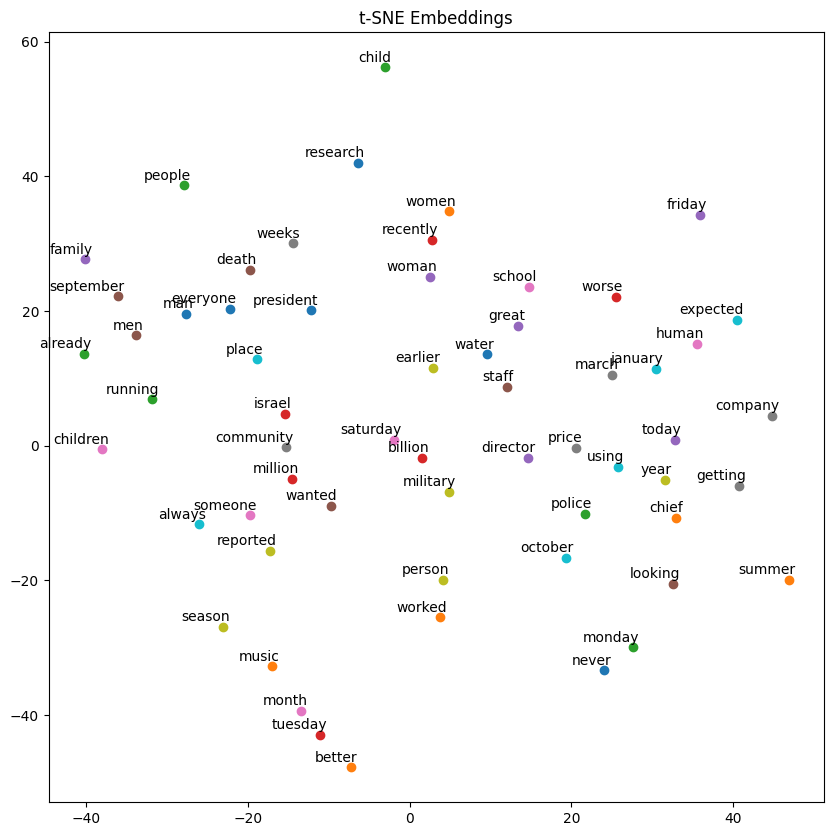

In [39]:
# Visualization BEFORE training -> random embeddings
embedding_shape = (VOCAB_SIZE, EMBEDDING_DIMS[0])
untrained_embeddings = np.random.randn(*embedding_shape)
visualize_tsne_embeddings(target_words, untrained_embeddings, word_to_index)

As we can see in the plot, the random embeddings do not have any kind of structure and the words are scattered randomly. Words do not have any similarity with the ones close to them. 

TODO: after running it one last time, we can comment here more explicitely with examples from the plots.

In [40]:
# 4. Load the target words for visualization
with open("materials/target_words.txt", "r") as f:
    target_words = [w.strip() for w in f if w.strip() in word_to_index]


print("Loading saved embeddings...")
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        try:
            embeddings_path = (
                f"embeddings/embeddings_w{w_size}_emb{e_dim}_v{VOCAB_SIZE}.npy"
            )
            experiments[(w_size, e_dim)]["embeddings"] = np.load(embeddings_path)
            print(f"  Successfully loaded: {embeddings_path}")
        except FileNotFoundError:
            print(f"  ! Could not find: {embeddings_path}")

Loading saved embeddings...
  Successfully loaded: embeddings/embeddings_w2_emb50_v20000.npy
  Successfully loaded: embeddings/embeddings_w2_emb100_v20000.npy
  Successfully loaded: embeddings/embeddings_w2_emb200_v20000.npy
  Successfully loaded: embeddings/embeddings_w4_emb50_v20000.npy
  Successfully loaded: embeddings/embeddings_w4_emb100_v20000.npy
  Successfully loaded: embeddings/embeddings_w4_emb200_v20000.npy
  Successfully loaded: embeddings/embeddings_w8_emb50_v20000.npy
  Successfully loaded: embeddings/embeddings_w8_emb100_v20000.npy
  Successfully loaded: embeddings/embeddings_w8_emb200_v20000.npy



 t-SNE visualization for window size 2 and embedding dim 50


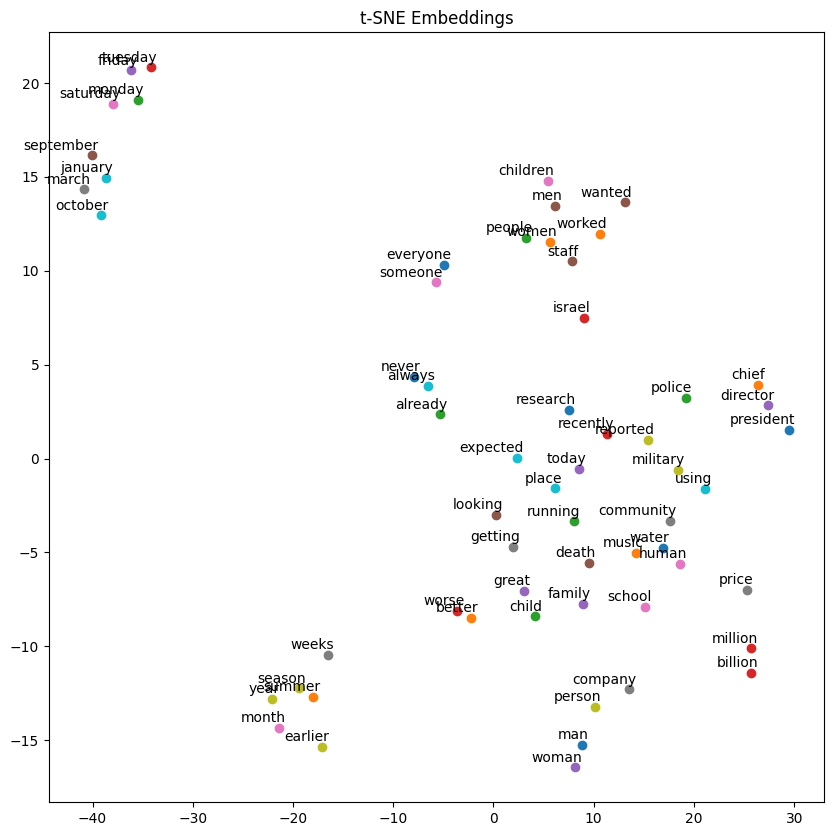


 t-SNE visualization for window size 2 and embedding dim 100


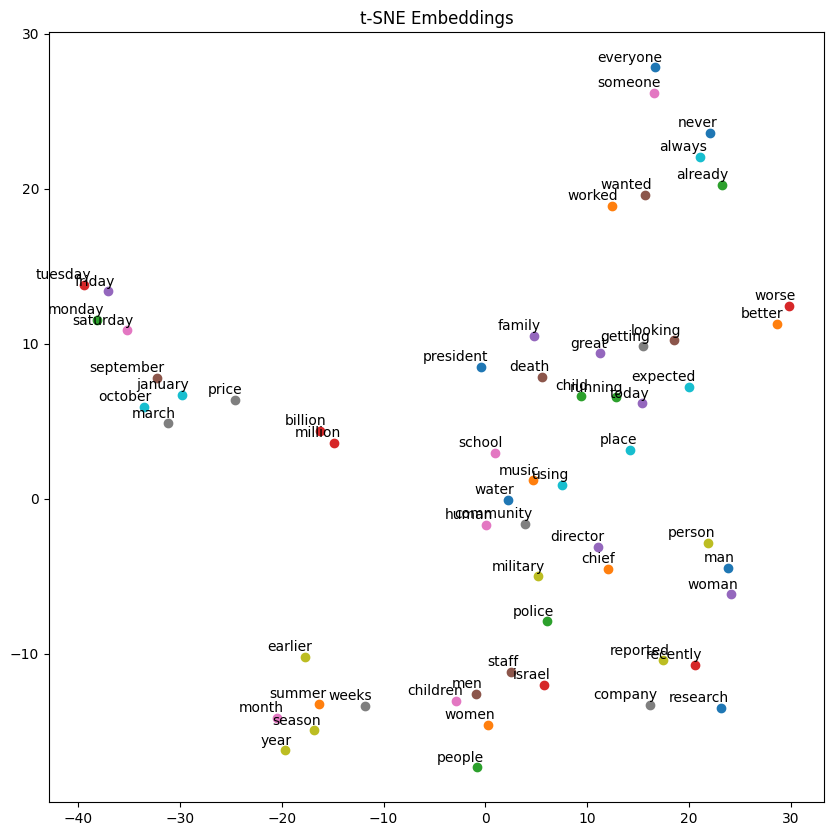


 t-SNE visualization for window size 2 and embedding dim 200


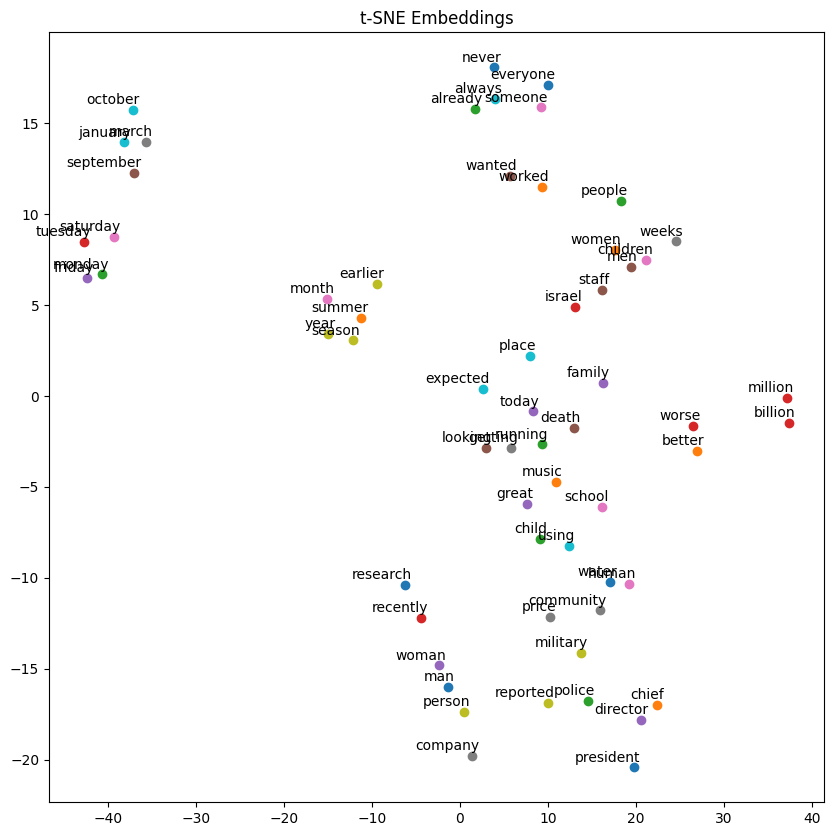


 t-SNE visualization for window size 4 and embedding dim 50


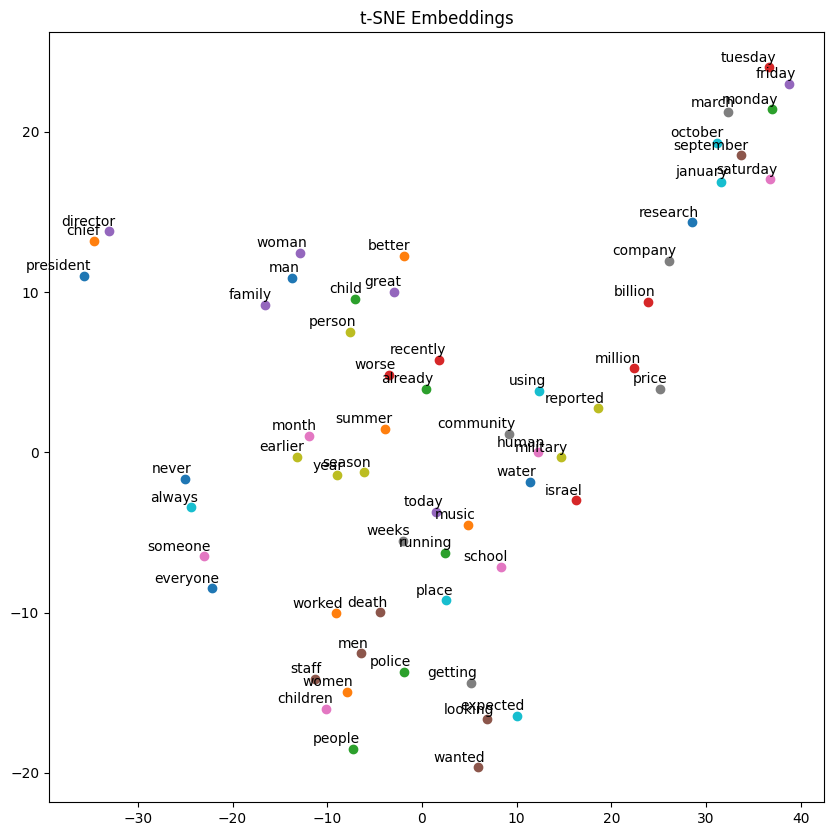


 t-SNE visualization for window size 4 and embedding dim 100


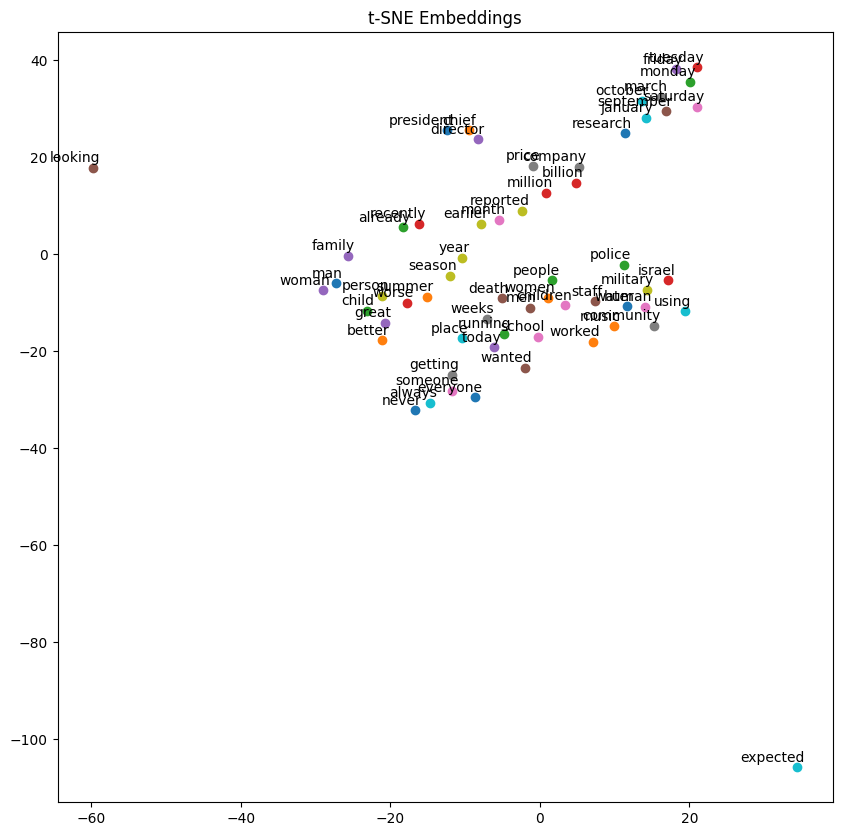


 t-SNE visualization for window size 4 and embedding dim 200


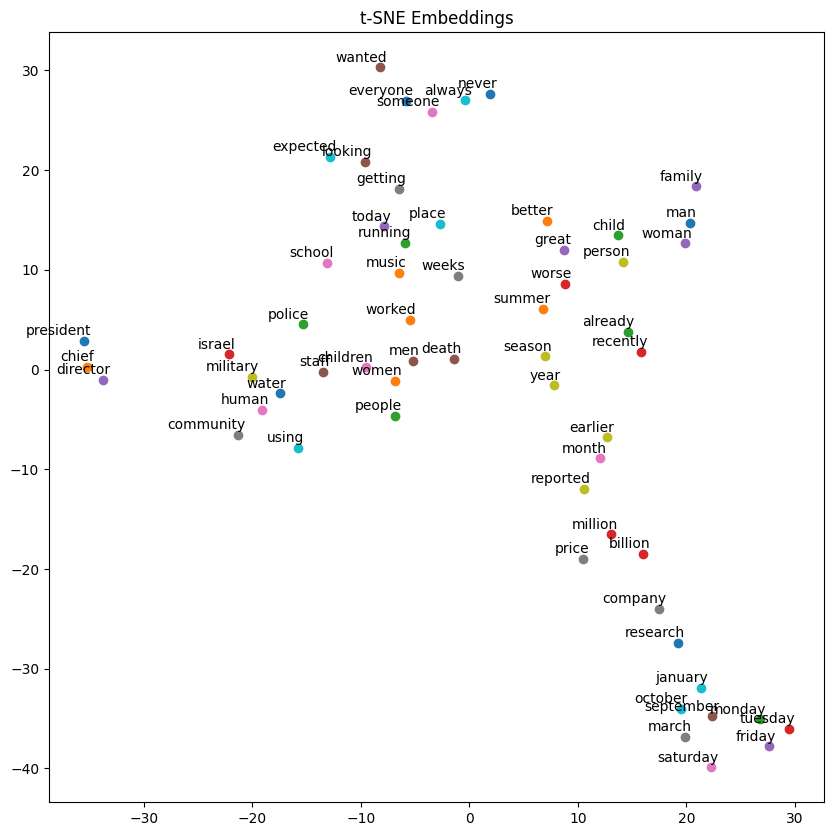


 t-SNE visualization for window size 8 and embedding dim 50


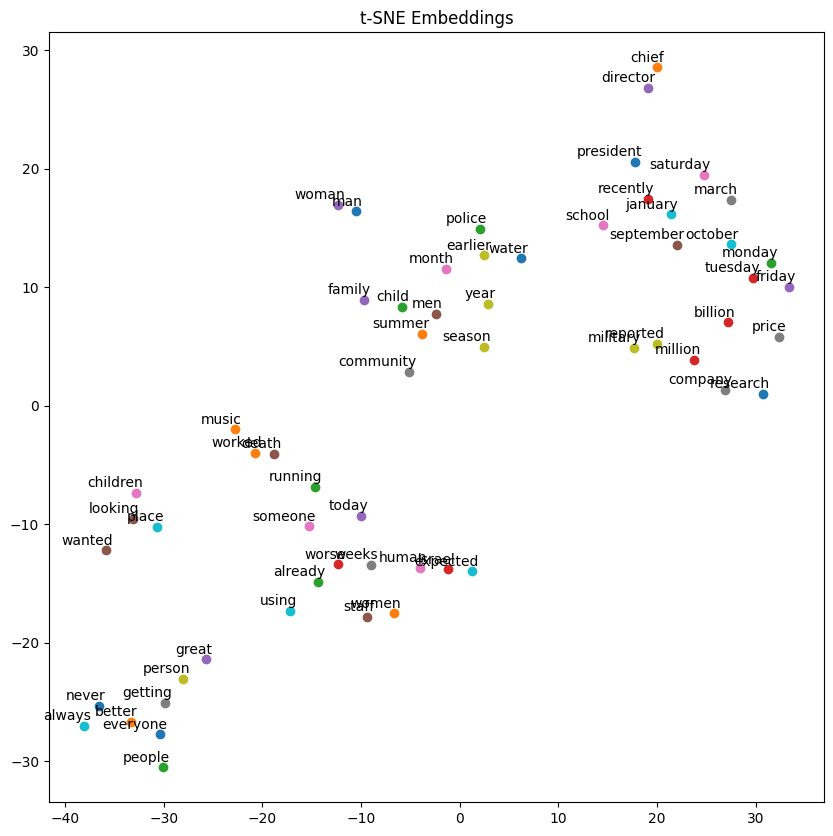


 t-SNE visualization for window size 8 and embedding dim 100


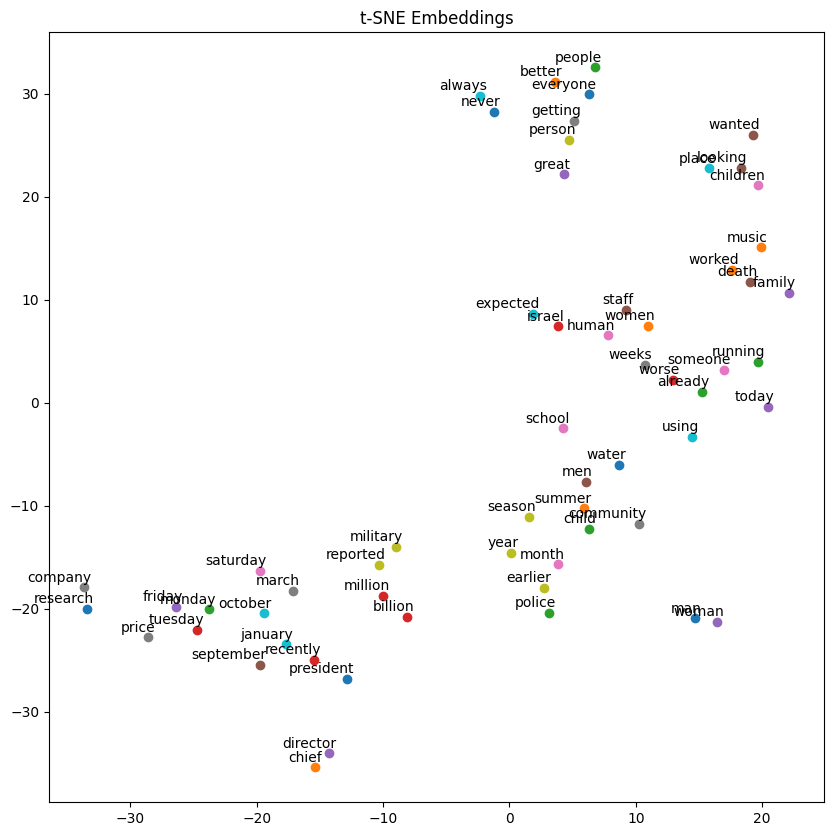


 t-SNE visualization for window size 8 and embedding dim 200


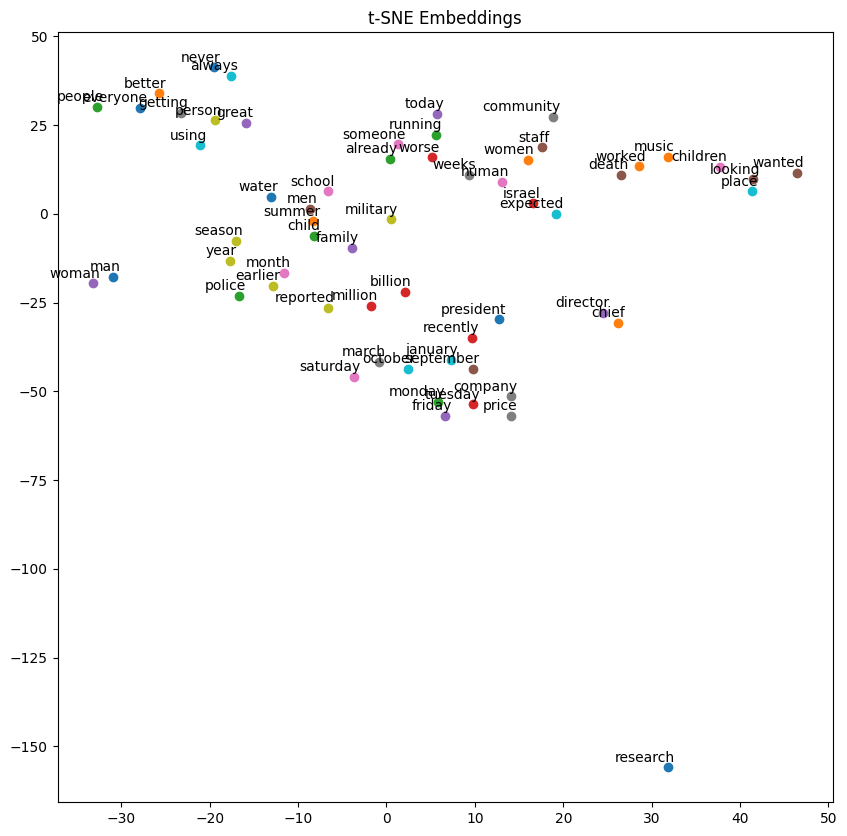

In [41]:
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\n t-SNE visualization for window size {w_size} and embedding dim {e_dim}"
        )
        embeddings = experiments[(w_size, e_dim)]["embeddings"]
        visualize_tsne_embeddings(target_words, embeddings, word_to_index)


--- Comparing t-SNE visualizations for Window Size = 2 ---


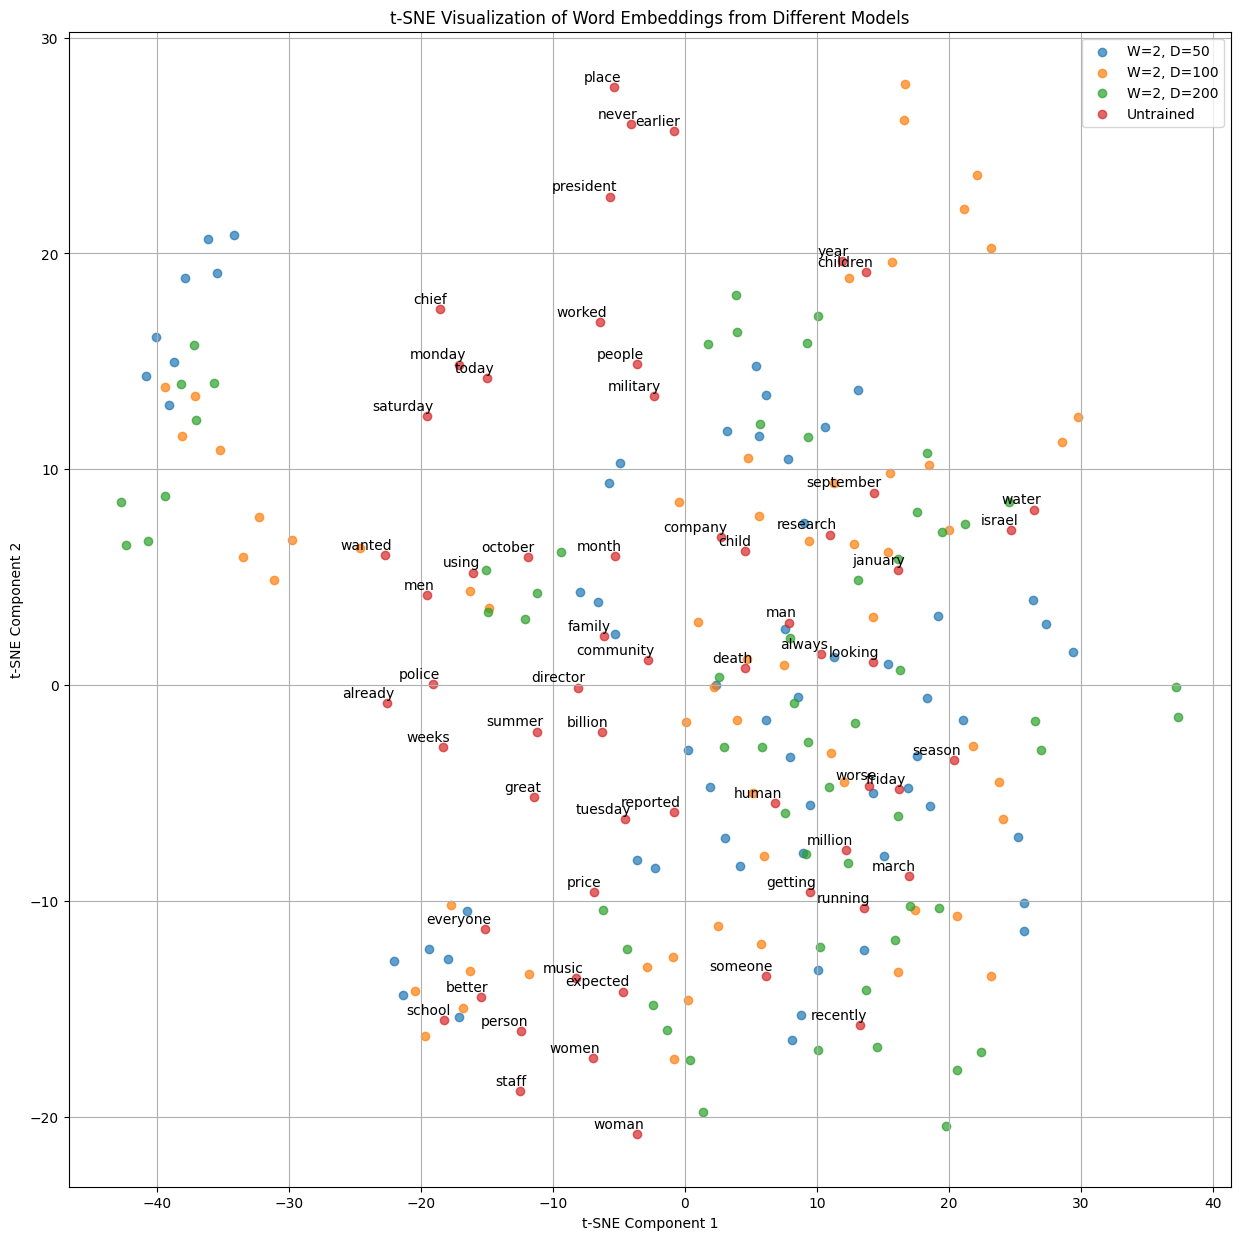


--- Comparing t-SNE visualizations for Window Size = 4 ---


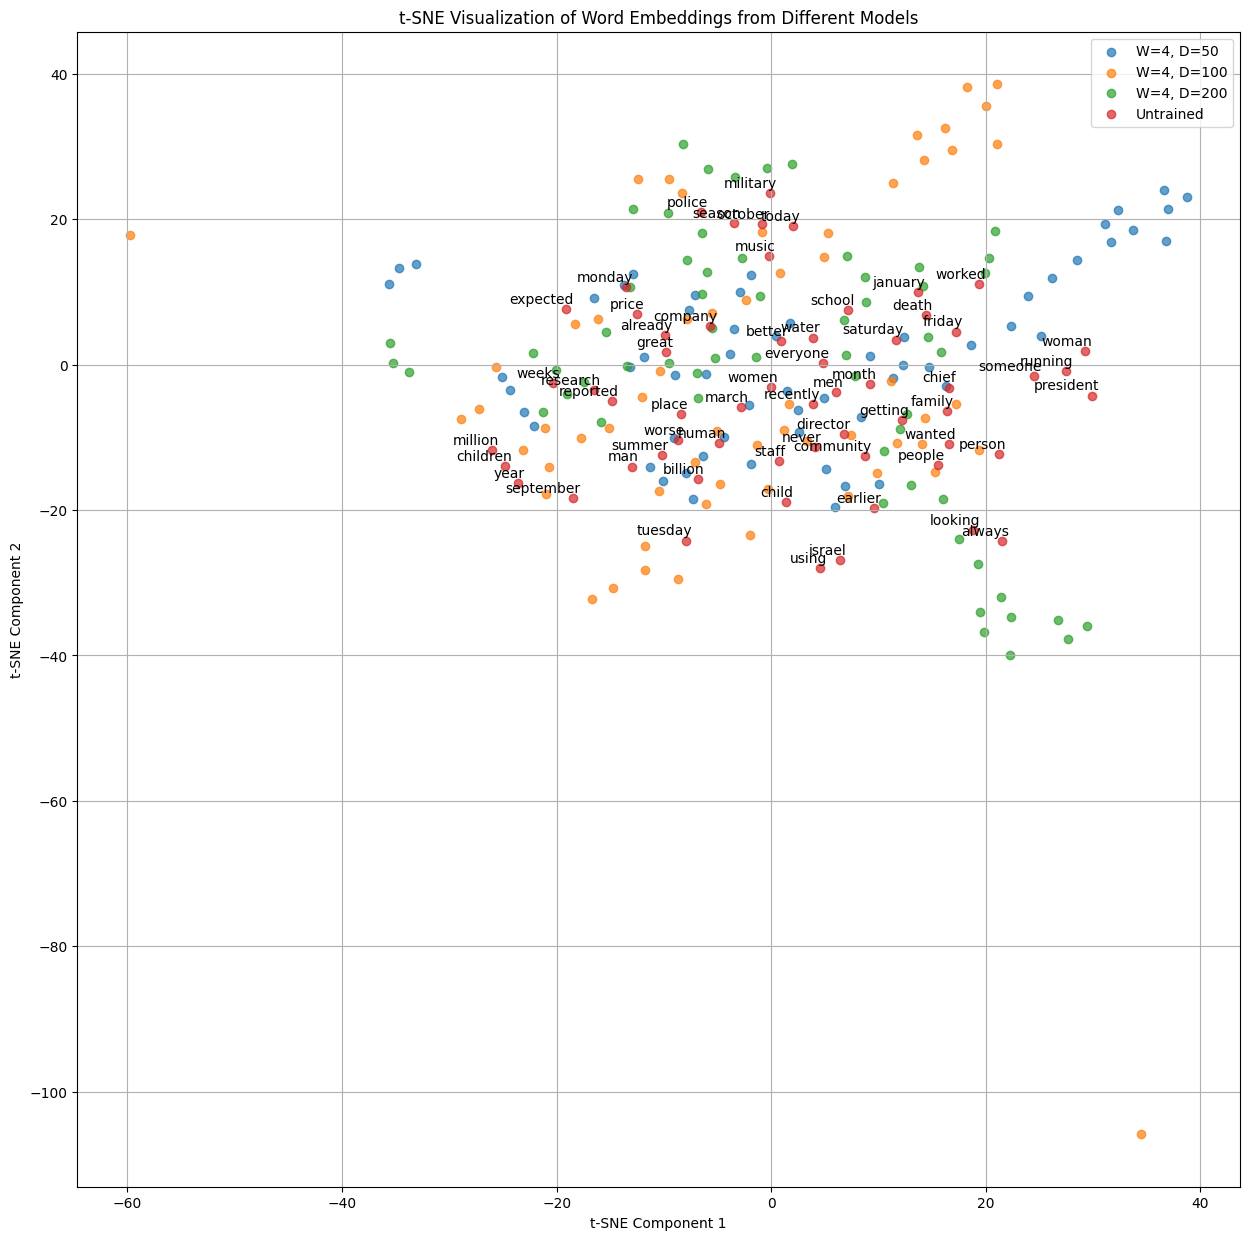


--- Comparing t-SNE visualizations for Window Size = 8 ---


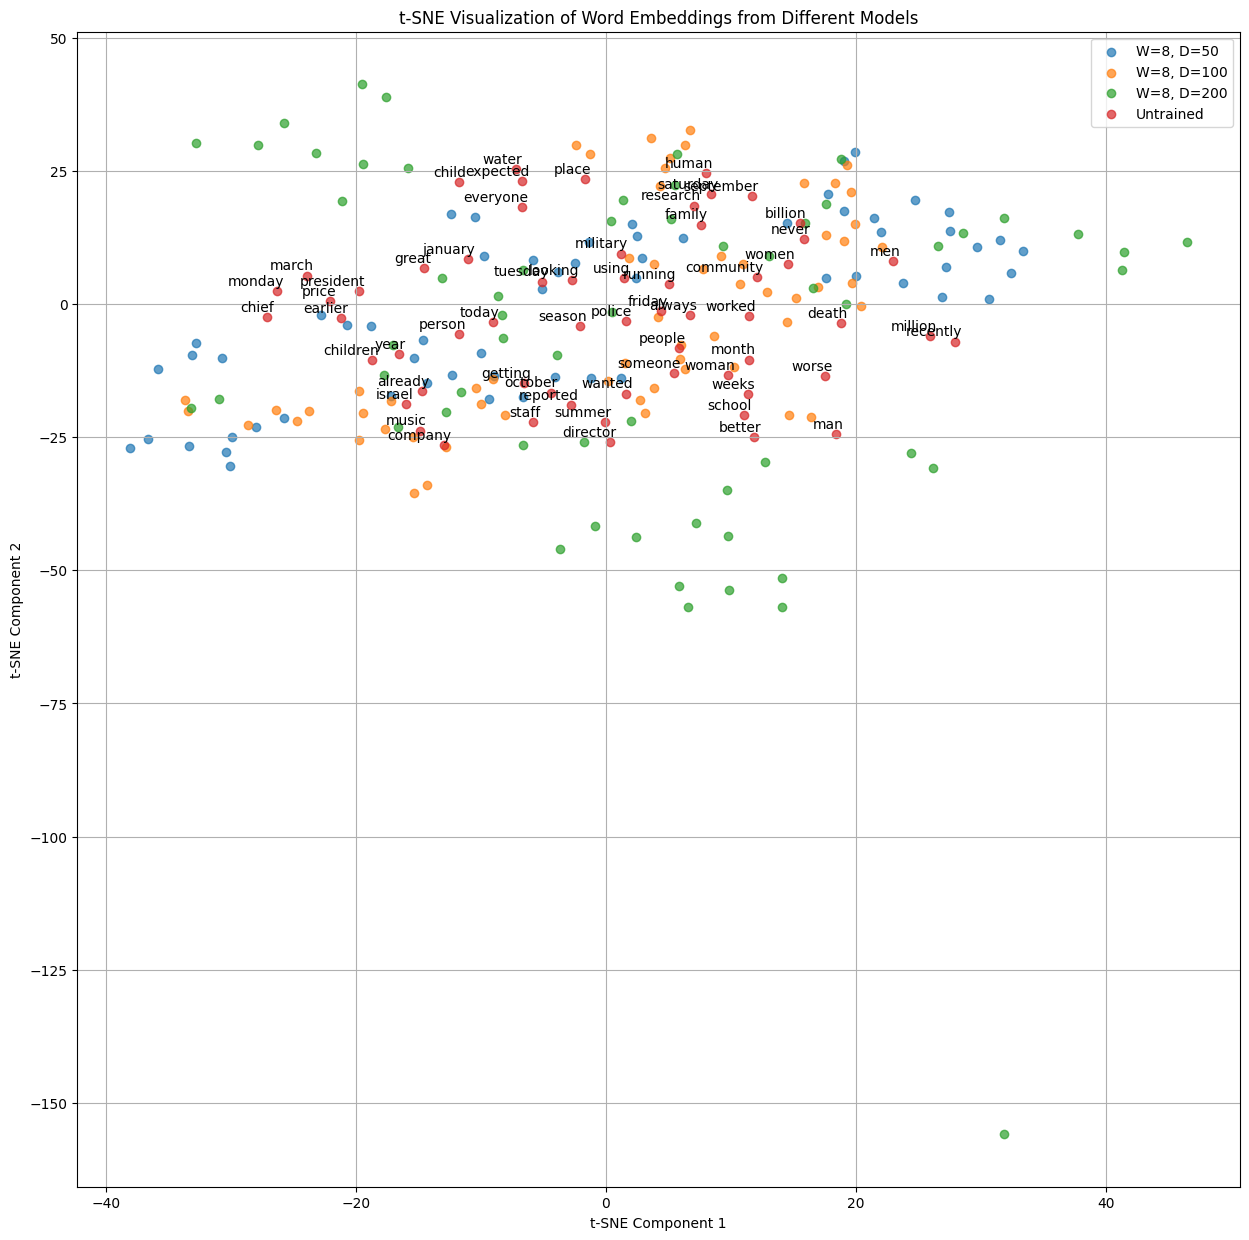

In [42]:
for w_size in WINDOW_SIZES:
    embeddings_to_compare = {}

    # Gather embeddings for the current window size
    for e_dim in EMBEDDING_DIMS:
        if (w_size, e_dim) in experiments and experiments[(w_size, e_dim)]["embeddings"] is not None:
            model_name = f"W={w_size}, D={e_dim}"
            embeddings_to_compare[model_name] = experiments[(w_size, e_dim)]["embeddings"]

    if embeddings_to_compare:
        # Add untrained embeddings for comparison
        any_trained_embedding = next(iter(embeddings_to_compare.values()))
        untrained_embeddings_for_plot = np.random.randn(*any_trained_embedding.shape)
        embeddings_to_compare["Untrained"] = untrained_embeddings_for_plot

        # Check if there's anything to compare
        if len(embeddings_to_compare) > 1:
            print(f"\n--- Comparing t-SNE visualizations for Window Size = {w_size} ---")
            visualize_all_tsne_embeddings(
                embeddings=embeddings_to_compare,
                word_index=word_to_index,
                words_to_plot=target_words
            )
        else:
            print(f"\nNot enough embeddings to compare for Window Size = {w_size}.")
    else:
        print(f"\nNo embeddings found for comparison for Window Size = {w_size}.")


## Training the Classification Models on the Reuters Dataset

In order to further evaluate the quality of the word embeddings we trained, we will use them as input to a classification model for the Reuters dataset. Since the Reuters dataset is different from the one used to train the embeddings, we also need to adapt the trained embeddings to the new dataset. We need to map the words from the Reuters ds to the words in our vocabulary and recreate the embedding matrix with the new vocabulary. 

In [57]:
from keras.datasets import reuters

MAX_LEN = 256


def build_classifier(
    embeddings_matrix=None,
    trainable=False,
    num_classes=46,
    max_len=256,
    vocab_size=20000,
) -> keras.Model:
    """
    Builds the classifier. If embeddings_matrix is provided, it uses our pre-trained embeddings.
    """
    input_dim = vocab_size if embeddings_matrix is None else embeddings_matrix.shape[0]
    output_dim = 100 if embeddings_matrix is None else embeddings_matrix.shape[1]

    inputs = layers.Input(shape=(max_len,), dtype="int32", name="input_tokens")
    embeds = None
    if embeddings_matrix is not None:
        print("Using PRE-TRAINED embeddings.")
        embeds = layers.Embedding(
            input_dim=embeddings_matrix.shape[0],
            output_dim=embeddings_matrix.shape[1],
            embeddings_initializer=keras.initializers.Constant(embeddings_matrix),
            trainable=trainable,  # Experiment with True vs False
        )(inputs)
    else:
        print("Using RANDOM (scratch) embeddings.")
        embeds = layers.Embedding(input_dim=input_dim, output_dim=output_dim)(inputs)

    # Standard 1D classification head
    x = layers.Conv1D(128, 5, activation="relu")(embeds)
    x = layers.MaxPooling1D(5)(x)
    x = layers.Conv1D(128, 5, activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    name = (
        "classifier_random_emb"
        if embeddings_matrix is None
        else "classifier_pretrained_emb"
    )
    model = keras.Model(inputs, outputs, name=f"{name}_v{vocab_size}")

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

def get_classifier_callbacks(model_path: str, patience: int = 5):
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    path = keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
    )

    return [early_stopping, path]

In [55]:
# Load the Reuters dataset from Keras
NUM_WORDS = len(vocab)  # Should ideally match the vocabulary size created in Phase 1
NUM_CLASSES = 46
MAX_LEN = 256

(x_train_reuters, y_train), (x_test_reuters, y_test) = reuters.load_data(
    num_words=NUM_WORDS, test_split=0.1, seed=SEED
)

# Pad sequences so they all have the same length
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train_reuters, maxlen=MAX_LEN)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test_reuters, maxlen=MAX_LEN)

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

word_index_reuters = reuters.get_word_index()
INDEX_FROM = 3  # word indices are offset by 3

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
def adapt_embeddings_to_reuters(
    pretrained_embeddings,
    word_to_index,
    word_index_reuters,
    embed_dim,
    num_words=20000,
    index_from=3,
):
    # initialize the embedding matrix of same size with random values
    embedding_matrix = np.random.uniform(-0.1, 0.1, size=(num_words, embed_dim))

    hits = 0
    misses = 0

    # Iterate over the target dataset and try to find the corresponding embeddings from the pretrained embeddings
    for word, i in word_index_reuters.items():

        actual_i = (
            i + index_from
        )  # since the ds word indices are offset by 3, we need to add that to get the correct index in our vocab
        if actual_i >= num_words:  # index out of range for our vocab size
            continue

        # If the word exists in our pretrained embeddings, copy it to the new embedding matrix
        if word in word_to_index:
            our_index = word_to_index[word]
            embedding_matrix[actual_i] = pretrained_embeddings[our_index]
            hits += 1
        else:
            misses += 1

        embedding_matrix[0] = np.zeros(pretrained_embeddings.shape[1])  # Padding token

    print(f"\nAdapted embeddings to Reuters vocab")
    print(f"HITS = {hits}, MISSES = {misses}\n")

    return embedding_matrix

### Baseline Model with Random Embeddings

To see how good our embeddings are, we first train a simple classification model inintilizing the embedding layer with random weights, and then train them alongside the classifcation model.

In [ ]:
baseline_model = build_classifier(embeddings_matrix=None)
callbacks = get_classifier_callbacks("models/classifier_rand_baseline.keras", 5)
baseline_history = baseline_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
)
baseline_loss, baseline_acc = baseline_model.evaluate(x_test, y_test, verbose=0)

print(f"Baseline Accuracy: {baseline_acc:.4f}")

Using RANDOM (scratch) embeddings.
Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4942 - loss: 1.9577 - val_accuracy: 0.5826 - val_loss: 1.6142
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6027 - loss: 1.5073 - val_accuracy: 0.6380 - val_loss: 1.4665
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6935 - loss: 1.2156 - val_accuracy: 0.7043 - val_loss: 1.3165
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7664 - loss: 0.9458 - val_accuracy: 0.7191 - val_loss: 1.4072
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8080 - loss: 0.7818 - val_accuracy: 0.7438 - val_loss: 1.3749
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8308 - loss: 0.6654 - val_accuracy: 0.7359 - val_loss: 1.4755
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8522 - loss: 0.5960 - val_accuracy: 0.7567 - val_loss: 1.5872
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accurac

### Classification Model with OUR Trained Embeddings

Now we can train the same classification model but this time we will initialize the embedding layer with the weights obtained from the word embedding models. We will compare the results obtained with the random embeddings and the ones obtained with the trained embeddings to see if there is an improvement in the classification performance.

In [ ]:
# Now we can train the classifier using the pre-trained embeddings from our word embedding models.
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\nClassifier with pre-trained embeddings of CONTEXT={w_size * 2} and EMBED_DIMS={e_dim}"
        )
        pretrained_embeddings = experiments[(w_size, e_dim)]["embeddings"]
        adapted_embeddings = adapt_embeddings_to_reuters(
            pretrained_embeddings,
            word_to_index,
            word_index_reuters,
            embed_dim=e_dim,
            num_words=VOCAB_SIZE,
            index_from=INDEX_FROM,
        )

        classifier_model = build_classifier(
            embeddings_matrix=adapted_embeddings,
            trainable=False,
            num_classes=NUM_CLASSES,
            max_len=MAX_LEN,
            vocab_size=VOCAB_SIZE,
        )
        callbacks = get_classifier_callbacks(
            f"models/classifier_pretrained_emb_w{w_size}_e{e_dim}.keras", 5
        )

        history = classifier_model.fit(
            x_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=2,
        )

        loss, acc = classifier_model.evaluate(x_test, y_test, verbose=0)
        print(f"Pre-trained embeddings classifier: {acc:.4f}")


Classifier with pre-trained embeddings of CONTEXT=4 and EMBED_DIMS=50

Adapted embeddings to Reuters vocab
HITS = 9385, MISSES = 10611

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/lm/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 - 6s - 20ms/step - accuracy: 0.4407 - loss: 2.5038 - val_accuracy: 0.5509 - val_loss: 1.8671
Epoch 2/50
285/285 - 4s - 16ms/step - accuracy: 0.5247 - loss: 2.0177 - val_accuracy: 0.5668 - val_loss: 1.7803
Epoch 3/50
285/285 - 5s - 16ms/step - accuracy: 0.5572 - loss: 1.8611 - val_accuracy: 0.5776 - val_loss: 1.7679
Epoch 4/50
285/285 - 5s - 17ms/step - accuracy: 0.5760 - loss: 1.7310 - val_accuracy: 0.5955 - val_loss: 1.6248
Epoch 5/50
285/285 - 5s - 16ms/step - accuracy: 0.5938 - loss: 1.6406 - val_accuracy: 0.5945 - val_loss: 1.6422
Epoch 6/50
285/285 - 5s - 16ms/step - accuracy: 0.6173 - loss: 1.5234 - val_accuracy: 0.6093 - val_loss: 1.5852
Epoch 7/50
285/285 - 4s - 15ms/step - accuracy: 0.6300 - loss: 1.4645 - val_accuracy: 0.5964 - val_loss: 1.7347
Epoch 8/50
285/285 - 5s - 16ms/step - accuracy: 0.6539 - loss: 1.3710 - val_accuracy: 0.6123 - val_loss: 1.7251
Epoch 9/50
285/285 - 5s - 16ms/step - accuracy: 0.6733 - loss: 1.2744 - val_accuracy: 0.6073 - val_loss: 1.6467
Epo

COMMENT THE RESULT HERE

### Classification model with Fine Tunning of the Embeddings

In [ ]:
# Now we can train the classifier using the pre-trained embeddings from our word embedding models.
for w_size, e_dim in [(w, e) for w in WINDOW_SIZES for e in EMBEDDING_DIMS]:
    if (w_size, e_dim) in experiments:
        print(
            f"\nClassifier with pre-trained embeddings of CONTEXT={w_size * 2} and EMBED_DIMS={e_dim}"
        )
        pretrained_embeddings = experiments[(w_size, e_dim)]["embeddings"]
        adapted_embeddings = adapt_embeddings_to_reuters(
            pretrained_embeddings,
            word_to_index,
            word_index_reuters,
            embed_dim=e_dim,
            num_words=VOCAB_SIZE,
            index_from=INDEX_FROM,
        )

        classifier_model = build_classifier(
            embeddings_matrix=pretrained_embeddings,
            trainable=True,
            num_classes=NUM_CLASSES,
            max_len=MAX_LEN,
            vocab_size=VOCAB_SIZE,
        )
        callbacks = get_classifier_callbacks(
            f"models/classifier_fine_tunned_emb_w{w_size}_e{e_dim}.keras", 5
        )

        history = classifier_model.fit(
            x_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=2,
        )

        loss, acc = classifier_model.evaluate(x_test, y_test, verbose=0)
        print(f"Pre-trained embeddings classifier: {acc:.4f}")


Classifier with pre-trained embeddings of CONTEXT=4 and EMBED_DIMS=50

Adapted embeddings to Reuters vocab
HITS = 9385, MISSES = 10611

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/dl/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 - 9s - 33ms/step - accuracy: 0.4592 - loss: 2.2934 - val_accuracy: 0.5509 - val_loss: 1.7695
Epoch 2/50
285/285 - 6s - 20ms/step - accuracy: 0.5584 - loss: 1.8347 - val_accuracy: 0.5935 - val_loss: 1.6223
Epoch 3/50
285/285 - 6s - 20ms/step - accuracy: 0.6083 - loss: 1.6056 - val_accuracy: 0.6390 - val_loss: 1.5248
Epoch 4/50
285/285 - 6s - 20ms/step - accuracy: 0.6616 - loss: 1.4282 - val_accuracy: 0.6588 - val_loss: 1.4758
Epoch 5/50
285/285 - 5s - 19ms/step - accuracy: 0.7109 - loss: 1.2186 - val_accuracy: 0.6884 - val_loss: 1.3973
Epoch 6/50
285/285 - 5s - 19ms/step - accuracy: 0.7424 - loss: 1.0605 - val_accuracy: 0.7072 - val_loss: 1.3722
Epoch 7/50
285/285 - 5s - 19ms/step - accuracy: 0.7744 - loss: 0.9128 - val_accuracy: 0.7141 - val_loss: 1.3887
Epoch 8/50
285/285 - 6s - 20ms/step - accuracy: 0.7962 - loss: 0.8061 - val_accuracy: 0.6973 - val_loss: 1.4883
Epoch 9/50
285/285 - 6s - 19ms/step - accuracy: 0.8182 - loss: 0.7104 - val_accuracy: 0.6845 - val_loss: 1.6389
Epo

COMMENT RESULTS HERE

### Classification model with GloVe Embeddings

In [44]:
import gensim.downloader as gsm

print(list(gsm.info()["models"].keys()))

# Load the GloVe embeddings (100-dimensional) from gensim's API
glove_model = gsm.load("glove-wiki-gigaword-100")
word2vec_model = gsm.load("word2vec-google-news-300")

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[==================================================] 100.0% 128.1/128.1MB downloaded
[==================================================] 100.0% 1662.8/1662.8MB downloaded


Following the same procedure as before, we will initialize the embedding layer with the GloVe embeddings and train the classification model. We have to adapt the GloVe embeddings to the reuters dataset as well, since again the vocabs are different.

In [47]:
def adapt_gensim_to_reuters_embeddings(
    gsm_model, word_index_reuters, embed_dim, num_words=20000, index_from=3
):
    # initialize the embedding matrix of same size with random values
    embedding_matrix = np.random.uniform(-0.1, 0.1, size=(num_words, embed_dim))

    hits = 0
    misses = 0

    # Iterate over the target dataset and try to find the corresponding embeddings from the pretrained embeddings
    for word, i in word_index_reuters.items():

        actual_i = (
            i + index_from
        )  # since the ds word indices are offset by 3, we need to add that to get the correct index in our vocab
        if actual_i >= num_words:  # index out of range for our vocab size
            continue

        # If the word exists in our pretrained embeddings, copy it to the new embedding matrix
        if word in gsm_model:
            embedding_matrix[actual_i] = gsm_model[word]
            hits += 1
        else:
            misses += 1

        embedding_matrix[0] = np.zeros(embed_dim)  # Padding token

    print(f"\nAdapted GloVe embeddings to Reuters vocab")
    print(f"HITS = {hits}, MISSES = {misses}\n")

    return embedding_matrix

In [ ]:
adapted_embeddings_glove = adapt_gensim_to_reuters_embeddings(
    glove_model,
    word_index_reuters,
    embed_dim=100,
    num_words=VOCAB_SIZE,
    index_from=INDEX_FROM,
)
glove_classifier_model = build_classifier(
    embeddings_matrix=adapted_embeddings_glove,
    trainable=False,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
)

callbacks = get_classifier_callbacks("models/classifier_glove_pretrained.keras", 5)

history = glove_classifier_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)


Adapted GloVe embeddings to Reuters vocab
HITS = 17684, MISSES = 2312

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/lm/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5280 - loss: 1.9821 - val_accuracy: 0.6152 - val_loss: 1.5536
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6483 - loss: 1.4812 - val_accuracy: 0.6993 - val_loss: 1.2166
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7049 - loss: 1.2185 - val_accuracy: 0.7379 - val_loss: 1.0962
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7450 - loss: 1.0382 - val_accuracy: 0.7577 - val_loss: 1.0140
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7788 - loss: 0.8822 - val_accuracy: 0.7735 - val_loss: 0.9668
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8068 - loss: 0.7543 - val_accuracy: 0.7715 - val_loss: 0.9690
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8277 - loss: 0.6730 - val_accuracy: 0.7893 - val_loss: 0.9511
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8507 - loss: 0.5663 - val_accuracy: 0.779

In [59]:
import seaborn as sns


def plot_keras_history(history, metrics=None):
    """
    Plots training and validation metrics using Seaborn.
    """
    # Use seaborn's nice default theme
    sns.set_theme(style="whitegrid")

    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = history_df.index + 1

    if metrics is None:
        # Auto-detect metrics, stripping out 'val_' prefixes
        metrics = [
            col
            for col in history_df.columns
            if not col.startswith("val_") and col != "epoch"
        ]

    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(7 * num_metrics, 5))

    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        val_metric = f"val_{metric}"
        if val_metric in history_df.columns:
            plot_data = history_df[["epoch", metric, val_metric]].melt(
                id_vars=["epoch"], var_name="Phase", value_name=metric.capitalize()
            )
            # Rename for legend clarity
            plot_data["Phase"] = plot_data["Phase"].replace(
                {metric: "Training", val_metric: "Validation"}
            )

            # Draw line plot
            sns.lineplot(
                data=plot_data,
                x="epoch",
                y=metric.capitalize(),
                hue="Phase",
                marker="o",
                ax=axes[i],
            )
        else:
            sns.lineplot(
                data=history_df,
                x="epoch",
                y=metric,
                marker="o",
                ax=axes[i],
                label="Training",
            )

        axes[i].set_title(f"{metric.capitalize()} over Epochs")
        axes[i].set_xlabel("Epoch")
        axes[i].set_ylabel(metric.capitalize())

    plt.tight_layout()
    plt.show()

GloVe Pre-trained Classifier Accuracy: 0.7898


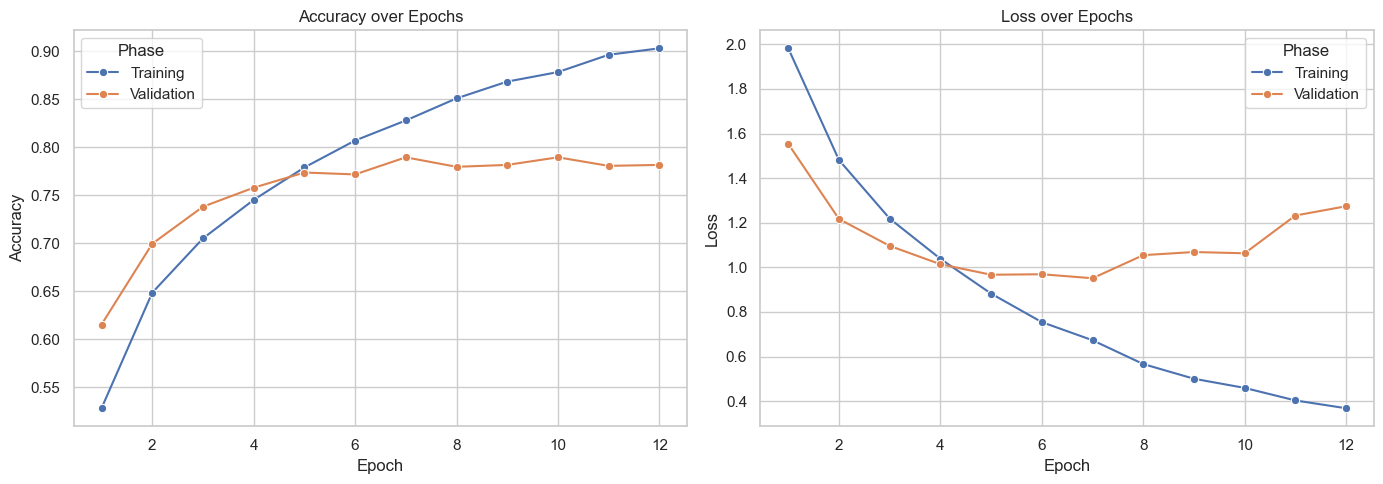

In [ ]:
test_loss, test_acc = glove_classifier_model.evaluate(x_test, y_test, verbose=0)
print(f"GloVe Pre-trained Classifier Accuracy: {test_acc:.4f}")
plot_keras_history(history, metrics=["accuracy", "loss"])


Adapted GloVe embeddings to Reuters vocab
HITS = 13658, MISSES = 6338

Using PRE-TRAINED embeddings.
Epoch 1/50


/Users/daniprieto/miniconda3/envs/lm/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


285/285 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5570 - loss: 1.8576 - val_accuracy: 0.6677 - val_loss: 1.2910
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6857 - loss: 1.3231 - val_accuracy: 0.7458 - val_loss: 1.0787
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7431 - loss: 1.0845 - val_accuracy: 0.7824 - val_loss: 0.9899
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7844 - loss: 0.8836 - val_accuracy: 0.7804 - val_loss: 0.9530
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8159 - loss: 0.7362 - val_accuracy: 0.7953 - val_loss: 0.9682
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8480 - loss: 0.6062 - val_accuracy: 0.7854 - val_loss: 1.0067
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8685 - loss: 0.5201 - val_accuracy: 0.7982 - val_loss: 0.9948
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8837 - loss: 0.4559 - val_accuracy: 0.802

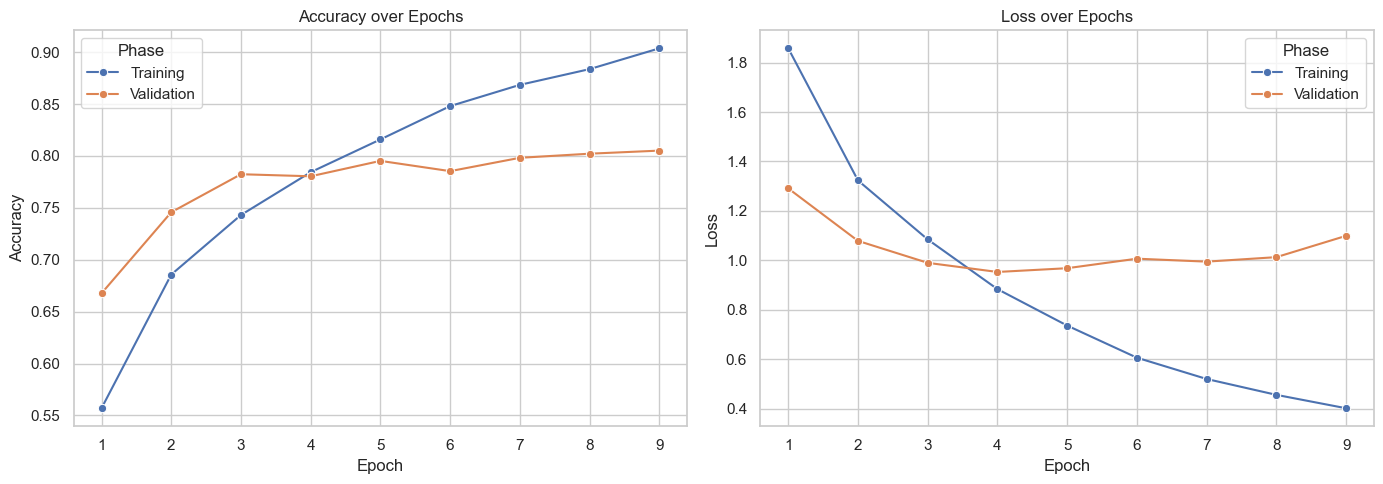

In [ ]:
word2vec_adapted_embeddings = adapt_gensim_to_reuters_embeddings(
    word2vec_model,
    word_index_reuters,
    embed_dim=300,
    num_words=VOCAB_SIZE,
    index_from=INDEX_FROM,
)
word2vec_classifier_model = build_classifier(
    embeddings_matrix=word2vec_adapted_embeddings,
    trainable=False,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
)

callbacks = get_classifier_callbacks("models/classifier_word2vec_pretrained.keras", 5)
history = word2vec_classifier_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)
test_loss, test_acc = word2vec_classifier_model.evaluate(x_test, y_test, verbose=0)
print(f"Word2Vec Pre-trained Classifier Accuracy: {test_acc:.4f}")
plot_keras_history(history, metrics=["accuracy", "loss"])

### Classification model with fastText Embeddings

In [45]:
fasttext_model = gsm.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded



Adapted GloVe embeddings to Reuters vocab
HITS = 15739, MISSES = 4257

Using PRE-TRAINED embeddings.
Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 22s 75ms/step - accuracy: 0.4528 - loss: 2.2622 - val_accuracy: 0.6696 - val_loss: 1.3712
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.6790 - loss: 1.3492 - val_accuracy: 0.7201 - val_loss: 1.1734
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.7521 - loss: 0.9964 - val_accuracy: 0.7587 - val_loss: 1.1091
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8063 - loss: 0.7796 - val_accuracy: 0.7656 - val_loss: 1.1224
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8466 - loss: 0.5821 - val_accuracy: 0.7794 - val_loss: 1.2405
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.8734 - loss: 0.4754 - val_accuracy: 0.7685 - val_loss: 1.3420
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8901 - loss: 0.4209 - val_accuracy: 0.7774 - val_l

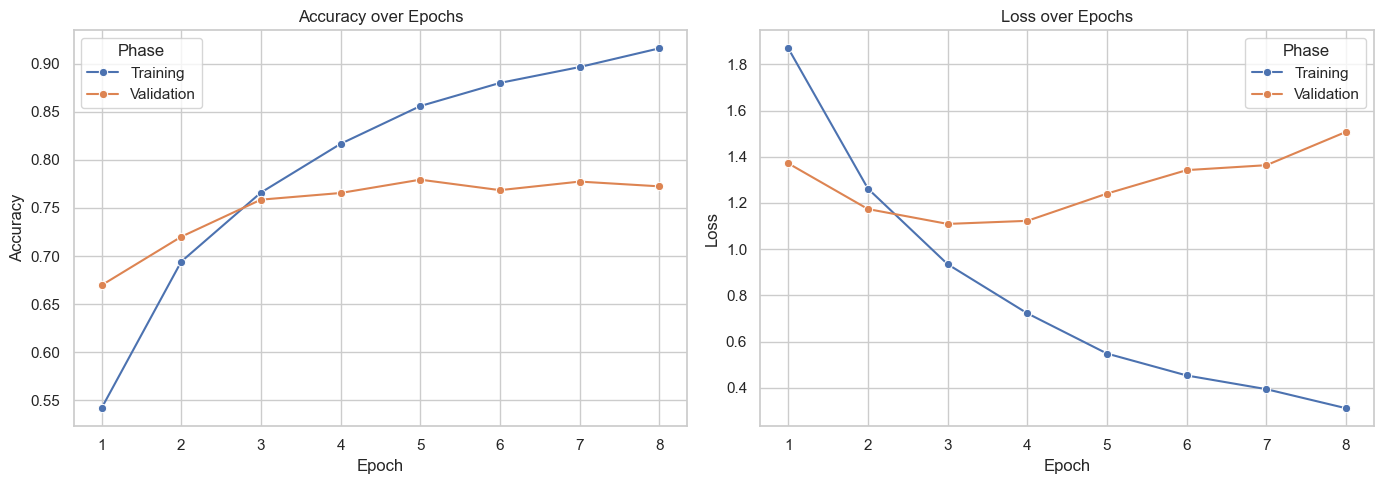

In [60]:
# Adapt the fastText embeddings to the Reuters vocabulary
fasttext_adapted_embeddings = adapt_gensim_to_reuters_embeddings(
    fasttext_model,
    word_index_reuters,
    embed_dim=300,  # fastText model has 300 dimensions
    num_words=VOCAB_SIZE,
    index_from=INDEX_FROM,
)

# Build the classifier with the adapted embeddings
fasttext_classifier_model = build_classifier(
    embeddings_matrix=fasttext_adapted_embeddings,
    trainable=False,  # Using them as static features
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    vocab_size=VOCAB_SIZE,
)

# Define callbacks and train the model
callbacks = get_classifier_callbacks("models/classifier_fasttext_pretrained.keras", 5)
history_fasttext = fasttext_classifier_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
)

# Evaluate and plot the results
test_loss, test_acc = fasttext_classifier_model.evaluate(x_test, y_test, verbose=0)
print(f"fastText Pre-trained Classifier Accuracy: {test_acc:.4f}")
plot_keras_history(history_fasttext, metrics=["accuracy", "loss"])